# Übung 4
**Mustererkennung und Maschinelles Lernen, SS 2026. Frist: 24.06.2026**

Hinweise:
* Auf Google Colab mit GPU ausführen (Laufzeit > Laufzeittyp ändern > GPU).
* Stellen mit `# TODO` und `...` ergänzen Sie selbst. Lassen Sie vorgegebenen Code möglichst unverändert.

## Aufgabe 1: Feature Maps und Parameteranzahl

Bitte als Scan/Foto oder LaTeX hier einfügen.

# Aufgabe 2: Merkmalsextraktion und Finetuning

Mit einem auf ImageNet vortrainierten MobileNetV2 und wenigen Daten bauen wir einen Klassifikator für den Datensatz `tf_flowers` (5 Blumenklassen): zuerst per Merkmalsextraktion (eingefrorene Basis), dann per Fine-Tuning.

In [2]:
# === Setup (vorgegeben) ===
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU verfügbar:", tf.config.list_physical_devices('GPU'))
#assert tf.config.list_physical_devices('GPU'), "Keine GPU! Laufzeit > Laufzeittyp ändern > GPU"

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow: 2.21.0
GPU verfügbar: []


## a) Datensatz laden und aufteilen (vorgegeben)

Split: 65 % Training / 15 % Validierung / 20 % Test, Trainingsmenge reduziert auf 1500 Bilder.

In [ ]:
# === Daten laden und aufteilen (vorgegeben) ===
(ds_train_raw, ds_val_raw, ds_test_raw), info = tfds.load(
    'tf_flowers',
    split=['train[:65%]', 'train[65%:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True,
)

NUM_CLASSES = info.features['label'].num_classes
class_names = info.features['label'].names
print("Klassen:", class_names)

N_TRAIN = 1500   # bewusst klein: Szenario "wenig Daten"
ds_train_raw = ds_train_raw.take(N_TRAIN)
print("Train:", sum(1 for _ in ds_train_raw),
      "| Val:", sum(1 for _ in ds_val_raw),
      "| Test:", sum(1 for _ in ds_test_raw))

plt.figure(figsize=(10, 6))
for i, (image, label) in enumerate(ds_train_raw.take(8)):
    plt.subplot(2, 4, i + 1)
    plt.imshow(image.numpy().astype('uint8'))
    plt.title(class_names[label.numpy()])
    plt.axis('off')
plt.tight_layout(); plt.show()

Warum wird hier neben einem Validierungsdatensatz noch ein Test-Set erzeugt?

In [ ]:
# === Preprocessing-Pipeline (vorgegeben) ===
# Skalieren auf 160x160, Wertebereich von MobileNetV2 ([-1, 1]), Batches, Prefetch.
IMG_SIZE = 160
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE
ds_train = (ds_train_raw.map(preprocess, num_parallel_calls=AUTOTUNE)
            .cache().shuffle(1000, seed=SEED).batch(BATCH_SIZE).prefetch(AUTOTUNE))
ds_val   = ds_val_raw.map(preprocess, num_parallel_calls=AUTOTUNE).cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_test  = ds_test_raw.map(preprocess, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

## b) Vortrainierte Basis laden und einfrieren

Laden Sie MobileNetV2 mit ImageNet-Gewichten ohne Klassifikationskopf und frieren Sie die
gesamte Faltungsbasis ein.

In [ ]:
base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=...,   # TODO
    weights=...,       # TODO
)

# TODO: Convolution-Basis einfrieren
...

print(f"Schichten in der Basis: {len(base_model.layers)}")
print(f"Parameter der Basis: {base_model.count_params():,}")

Wie viele Parameter hat die Basis, wie viele Trainingsbilder haben Sie? Wäre es sinnvoll, das gesamte Netz von Grund auf mit diesen Bildern zu trainieren?

## c) Neuen Klassifikator aufsetzen und trainieren (Merkmalsextraktion)

Setzen Sie auf die eingefrorene Basis: GlobalAveragePooling2D, Dropout(0.2), Dense mit passender Ausgabegrösse und Aktivierung. Trainiert wird nur dieser Kopf.

Welche Validierungs-Accuracy erwarten Sie nach 10 Epochen, in denen nur der Kopf trainiert wird: eher 30 %, 60 % oder 90 %? Kurze Begründung.

In [ ]:
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)   # nicht ändern (BatchNorm)

# TODO: GlobalAveragePooling2D, Dropout(0.2), Dense(?, activation=?)
x = ...
x = ...
outputs = ...

model = keras.Model(inputs, outputs)

# TODO: kompilieren. Welche Loss-Funktion passt zu ganzzahligen Labels (0..4) und Softmax?
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              loss=...,   # TODO
              metrics=['accuracy'])
model.summary(show_trainable=True)

Wie viele trainierbare Parameter hat das Modell jetzt (siehe summary)?

Warum vermeidet GlobalAveragePooling das Flatten+Dense-Problem aus Aufgabe 1c?

In [ ]:
# === Training Phase 1 (vorgegeben) ===
EPOCHS_FE = 10
history_fe = model.fit(ds_train, validation_data=ds_val, epochs=EPOCHS_FE)

In [ ]:
# === Plot-Funktion (vorgegeben) ===
def plot_history(histories, title, vline=None):
    acc, val_acc, loss, val_loss = [], [], [], []
    for h in histories:
        acc += h.history['accuracy']; val_acc += h.history['val_accuracy']
        loss += h.history['loss'];    val_loss += h.history['val_loss']
    epochs = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, acc, 'o-', label='Training')
    axes[0].plot(epochs, val_acc, 's-', label='Validierung')
    axes[0].set_xlabel('Epoche'); axes[0].set_ylabel('Accuracy'); axes[0].set_title('Genauigkeit')
    axes[1].plot(epochs, loss, 'o-', label='Training')
    axes[1].plot(epochs, val_loss, 's-', label='Validierung')
    axes[1].set_xlabel('Epoche'); axes[1].set_ylabel('Loss'); axes[1].set_title('Verlust')
    for ax in axes:
        if vline is not None:
            ax.axvline(vline + 0.5, color='gray', ls='--', label='Start Fine-Tuning')
        ax.legend(); ax.grid(alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout(); plt.show()

plot_history([history_fe], 'Phase 1: Merkmalsextraktion (Basis eingefroren)')

Vergleichen Sie mit Ihrer Vorhersage. Wie nah liegen Trainings- und Validierungskurve beieinander, sehen Sie Overfitting? Warum (nicht)?

## d) Fine-Tuning der oberen Faltungsschichten

Geben Sie die oberen Schichten der Basis frei und trainieren Sie mit sehr kleiner Lernrate weiter.

Wählen Sie ein `FINE_TUNE_AT`, also ab welcher der 154 Schichten trainiert wird (sinnvoll: ca. 50 bis 140). Begründen Sie.

Was denken Sie, wie die Kurven in den Epochen 11 bis 20 weiterlaufen. Steigt, stagniert oder fällt die Validierungs-Accuracy?

Wichtig: Nach jeder Änderung von `trainable` muss neu kompiliert werden, sonst hat sie keinen Effekt.

In [ ]:
base_model.trainable = True

FINE_TUNE_AT = ...   # TODO (Freie Wahl, ca. 50 bis 140)
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# TODO: neu kompilieren, mit deutlich kleinerer Lernrate (Empfehlung aus dem Blatt: 1e-5)
model.compile(optimizer=...,   # TODO
              loss=...,        # TODO (wie oben)
              metrics=['accuracy'])

n_trainable = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
print(f"Trainierbare Parameter jetzt: {n_trainable:,}")

EPOCHS_FT = 10
history_ft = model.fit(ds_train, validation_data=ds_val,
                       epochs=EPOCHS_FE + EPOCHS_FT,
                       initial_epoch=EPOCHS_FE)

In [ ]:
plot_history([history_fe, history_ft],
             'Merkmalsextraktion (Epochen 1-10) + Fine-Tuning (Epochen 11-20)',
             vline=EPOCHS_FE)

test_loss, test_acc = model.evaluate(ds_test, verbose=0)
print(f"Test-Accuracy nach Fine-Tuning: {test_acc:.3f}")

## e) Diskussion

Warum trainiert man beim Fine-Tuning mit einer so kleinen Lernrate?

Warum gibt man nur die oberen Schichten frei und nicht die unteren?

# Aufgabe 3: Embeddings als Repräsentationen

Ein Feature-Extractor bildet jedes Bild auf einen Vektor (Embedding) ab. Wir prüfen, ob diese
Embeddings semantisch sinnvoll sind: Bleiben sich ähnliche Ziffern auch im Embedding-Raum nahe?

Als Extractor dient ein LeNet-5, das fertig vorgegeben ist und auf MNIST schnell trainiert ist. Ihre Aufgabe beginnt danach: Embeddings extrahieren und untersuchen.

In [3]:
# === MNIST laden (vorgegeben) ===
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train_norm = x_train[..., None].astype('float32') / 255.0
x_test_norm  = x_test[..., None].astype('float32') / 255.0
print("Trainingsdaten:", x_train_norm.shape)

Trainingsdaten: (60000, 28, 28, 1)


In [4]:
# === Feature-Extractor: LeNet-5 trainieren (vorgegeben, nur ausführen) ===
# LeNet-5 (LeCun et al., 1998) ist eine der ersten erfolgreichen CNN-Architekturen
# und wurde für genau diese Aufgabe entworfen: handgeschriebene Ziffern.
# Wir bleiben nahe am Original (tanh-Aktivierung, Average Pooling); moderne Netze
# verwenden stattdessen meist ReLU und Max Pooling.

inp = keras.Input(shape=(28, 28, 1))
h = layers.Conv2D(6, 5, padding='same', activation='tanh')(inp)   # C1
h = layers.AveragePooling2D(2)(h)                                 # S2
h = layers.Conv2D(16, 5, activation='tanh')(h)                    # C3
h = layers.AveragePooling2D(2)(h)                                 # S4
h = layers.Flatten()(h)
h = layers.Dense(120, activation='tanh')(h)                       # C5
h = layers.Dense(84, activation='tanh', name='embedding')(h)      # F6
out = layers.Dense(10, activation='softmax')(h)
lenet = keras.Model(inp, out, name='LeNet5')

lenet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lenet.fit(x_train_norm, y_train, epochs=5, batch_size=128, validation_split=0.1, verbose=2)
print('Test-Accuracy:', lenet.evaluate(x_test_norm, y_test, verbose=0)[1])

Epoch 1/5
422/422 - 6s - 14ms/step - accuracy: 0.8972 - loss: 0.3542 - val_accuracy: 0.9642 - val_loss: 0.1308
Epoch 2/5
422/422 - 5s - 12ms/step - accuracy: 0.9595 - loss: 0.1346 - val_accuracy: 0.9750 - val_loss: 0.0849
Epoch 3/5
422/422 - 4s - 9ms/step - accuracy: 0.9739 - loss: 0.0867 - val_accuracy: 0.9797 - val_loss: 0.0722
Epoch 4/5
422/422 - 6s - 14ms/step - accuracy: 0.9806 - loss: 0.0637 - val_accuracy: 0.9808 - val_loss: 0.0625
Epoch 5/5
422/422 - 4s - 10ms/step - accuracy: 0.9849 - loss: 0.0493 - val_accuracy: 0.9845 - val_loss: 0.0542
Test-Accuracy: 0.9825000166893005


## a) Balancierte Teilmenge ziehen und normalisieren

Schreiben Sie `balanced_subset`: pro Ziffer genau `n_per_class` zufällige Bilder ohne Zurücklegen,
gemischt zurückgeben. Danach Pixel auf [0, 1] normalisieren.
Bausteine: `np.where(y == c)[0]`, `rng.choice(..., replace=False)`, `np.concatenate`, `rng.shuffle`.

In [5]:
def balanced_subset(x, y, n_per_class, seed=42):
    rng = np.random.default_rng(seed)

    # Wir ziehen für jede Ziffer 0 bis 9 genau gleich viele Beispiele.
    # Dadurch ist die Teilmenge balanciert: keine Ziffer kommt häufiger vor
    # und beeinflusst t-SNE oder K-Means stärker als die anderen.
    all_indices = []
    for c in range(10):
        indices_c = np.where(y == c)[0]
        chosen_c = rng.choice(indices_c, size=n_per_class, replace=False)
        all_indices.append(chosen_c)

    # Aus den zehn kleinen Index-Listen wird eine große Liste gebaut.
    # Danach mischen wir, damit die Bilder nicht nach Klassen sortiert sind.
    idx = np.concatenate(all_indices)
    rng.shuffle(idx)

    return x[idx], y[idx]

N_PER_CLASS = 250   # 2500 Bilder, für Vergleichbarkeit nicht ändern
x_sub, y_sub = balanced_subset(x_train, y_train, N_PER_CLASS)

# Die Rohdaten liegen als Grauwerte von 0 bis 255 vor.
# Für das trainierte Netz brauchen wir wieder Werte im Bereich [0, 1].
x_sub = x_sub.astype('float32') / 255.0

# Selbsttest (vorgegeben), muss ohne Fehler durchlaufen:
assert x_sub.shape == (2500, 28, 28) and x_sub.max() <= 1.0
assert np.all(np.bincount(y_sub) == N_PER_CLASS), "Teilmenge ist nicht klassenbalanciert!"
print("OK. Teilmenge:", x_sub.shape, "| Klassenverteilung:", np.bincount(y_sub))


OK. Teilmenge: (2500, 28, 28) | Klassenverteilung: [250 250 250 250 250 250 250 250 250 250]


## b) Extractor bauen und Embeddings berechnen

Erstellen Sie aus dem trainierten LeNet ein Teilmodell bis zur Schicht `embedding` und berechnen
Sie mit einem `predict`-Aufruf für jedes Bild ein Embedding.
Hinweis: `lenet.get_layer('embedding').output` liefert den Ausgang der Schicht; daraus lässt sich
mit `keras.Model(...)` ein Teilmodell bauen. Eingabeform: `x_sub[..., None]`.

In [6]:
# Das fertige LeNet endet mit einer Softmax-Ausgabe für die 10 Ziffern.
# Für Embeddings wollen wir aber nicht die finale Klasse, sondern die 84-dimensionalen
# Merkmale aus der Schicht mit dem Namen "embedding".
extractor = keras.Model(
    inputs=lenet.input,
    outputs=lenet.get_layer('embedding').output
)

# x_sub hat noch die Form (2500, 28, 28).
# Das CNN erwartet aber (2500, 28, 28, 1), also ergänzen wir den Kanal mit [..., None].
# Danach liefert predict für jedes Bild einen 84-dimensionalen Embedding-Vektor.
embeddings = extractor.predict(x_sub[..., None], batch_size=128, verbose=0)

print('Form der Embeddings:', embeddings.shape)


Form der Embeddings: (2500, 84)


Welche Dimension hat ein einzelnes Embedding? Um welchen Faktor wurde die
Darstellung gegen?ber den Rohpixeln (28x28 = 784 Werte) reduziert?

**Antwort:**

Ein einzelnes Embedding hat die Dimension **84**, weil die Schicht `embedding` im LeNet so definiert ist:

```python
layers.Dense(84, activation='tanh', name='embedding')
```

Ein MNIST-Rohbild hat `28 * 28 = 784` Pixelwerte. Die Darstellung wird also von `784` Werten auf `84` Werte reduziert.

Der Reduktionsfaktor ist:

```text
784 / 84 ? 9.33
```

Das Embedding ist also ungef?hr **9.3-mal kompakter** als das Rohbild. Wichtig ist: Es ist nicht nur kleiner, sondern soll die f?r die Ziffernerkennung wichtigen Informationen konzentrieren. Unwichtige Details wie kleine Verschiebungen, Strichdicke oder Rauschen sollen weniger stark z?hlen als die eigentliche Ziffernstruktur.


## c) Baseline: t-SNE auf Rohpixeln

Wenden Sie t-SNE direkt auf die flachgemachten Rohpixel an (jedes Bild als 784-dim Vektor) und
plotten Sie das Ergebnis eingefärbt nach der wahren Ziffer.

Vorgeschlagene Parameter: `perplexity=30, init='pca', learning_rate='auto',
random_state=SEED`.

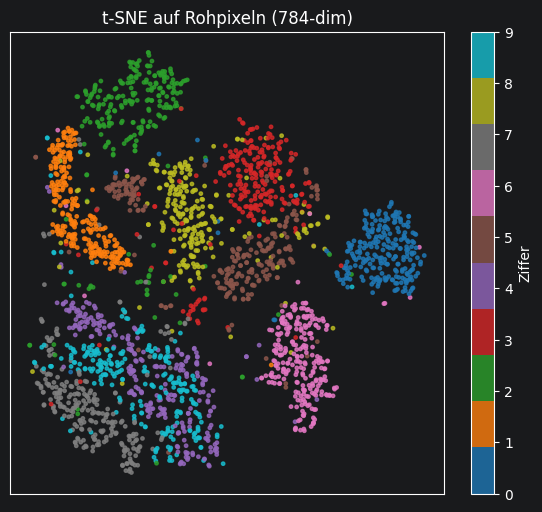

In [7]:
from sklearn.manifold import TSNE

# === Plot-Funktion (vorgegeben) ===
def plot_tsne(points_2d, labels, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(points_2d[:, 0], points_2d[:, 1], c=labels, cmap='tab10', s=6, alpha=0.8)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    return sc

# Für die Rohpixel-Baseline wird jedes 28x28-Bild zu einem langen Vektor
# mit 784 Einträgen gemacht. Dabei geht die 2D-Struktur des Bildes verloren.
x_flat = x_sub.reshape(len(x_sub), -1)

# t-SNE reduziert die 784-dimensionalen Rohpixel auf 2 Dimensionen,
# damit wir die Bilder als Punkte plotten können. Die Farben sind die echten Labels.
z_raw = TSNE(
    n_components=2,
    perplexity=30,
    init='pca',
    learning_rate='auto',
    random_state=42
).fit_transform(x_flat)

fig, ax = plt.subplots(figsize=(7, 6))
sc = plot_tsne(z_raw, y_sub, 't-SNE auf Rohpixeln (784-dim)', ax)
fig.colorbar(sc, ax=ax, ticks=range(10), label='Ziffer')
plt.show()


**Rohpixel nach T-sNE**

In dieser Grafik sieht man, wie gut sich die Ziffern allein anhand der ursprünglichen Pixelwerte gruppieren. Meist entstehen bereits einige erkennbare Bereiche, weil gleiche Ziffern oft ähnliche Strichmuster haben. Die Trennung ist aber noch nicht optimal: Manche Farben liegen dicht beieinander oder mischen sich.

Das ist plausibel, weil Rohpixel nur direkte Bildähnlichkeit messen. Zwei Bilder können pixelweise unterschiedlich aussehen, obwohl sie dieselbe Ziffer zeigen, zum Beispiel wenn eine `7` etwas schräger geschrieben ist. Umgekehrt können verschiedene Ziffern lokal ähnlich aussehen, etwa `3` und `8` oder `4` und `9`.
Durch die art und Weise wie T-sNE funktioniert ist keine ordnung in den Daten also 9 und 6 können durch den Zufallsanteil nicht unterschieden werden.


## d) t-SNE auf den Embeddings und Vergleich

Vor dem Ausf?hren: Erwarten Sie auf den Embeddings klarere oder unklarere Cluster als auf den Rohpixeln? Warum? Welche Ziffernpaare k?nnten in beiden F?llen schwer zu trennen sein?

**Erwartung:**

Ich erwarte auf den Embeddings **klarere Cluster** als auf den Rohpixeln. Der Grund ist, dass das LeNet bereits auf MNIST trainiert wurde. Die Embedding-Schicht enthält daher nicht mehr nur einzelne Pixelwerte, sondern gelernte Merkmale, die für die Ziffernklassifikation nützlich sind.

Bei den Rohpixeln bedeutet Nähe hauptsächlich: Die Bilder sehen pixelweise ähnlich aus. Bei den Embeddings sollte Nähe eher bedeuten: Die Bilder gehören semantisch zur gleichen Ziffer oder haben ähnliche zifferntypische Formen.

Schwierige Ziffernpaare könnten sein:

- `3` und `8`, weil beide Rundungen enthalten können.
- `4` und `9`, wenn die Schreibweise der `4` geschlossen wirkt.
- `5` und `8`, weil eine undeutliche `5` wie ein Teil einer `8` aussehen kann.
- `1` und `7`, wenn die `7` ohne Querstrich geschrieben ist.
- `0` und `6`, wenn die öffnung der `6` klein ist.


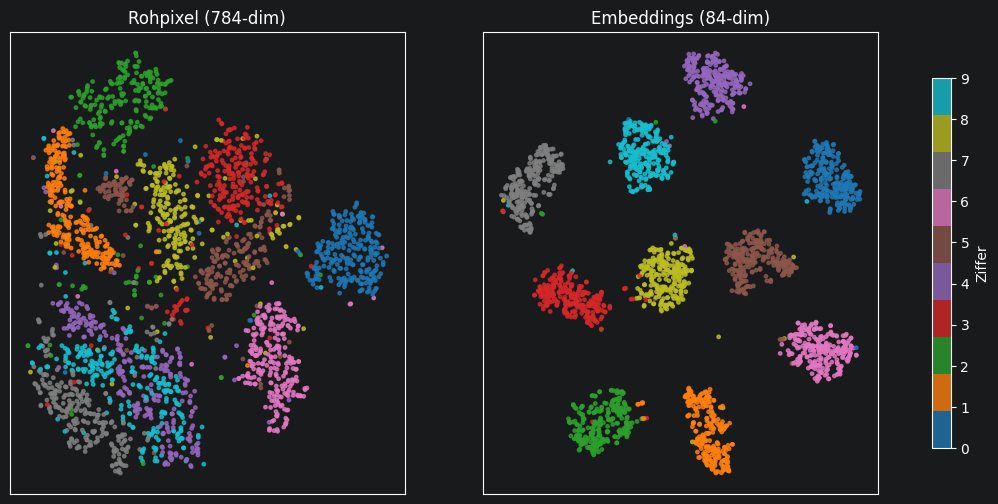

In [8]:
# t-SNE wird jetzt nicht auf den Rohpixeln, sondern auf den gelernten Embeddings ausgeführt.
# Die Parameter bleiben gleich, damit der Vergleich fair ist.
z_emb = TSNE(
    n_components=2,
    perplexity=30,
    init='pca',
    learning_rate='auto',
    random_state=42
).fit_transform(embeddings)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_tsne(z_raw, y_sub, 'Rohpixel (784-dim)', axes[0])
sc = plot_tsne(z_emb, y_sub, f'Embeddings ({embeddings.shape[1]}-dim)', axes[1])
fig.colorbar(sc, ax=axes, ticks=range(10), label='Ziffer', shrink=0.8)
plt.show()


In welchem Fall bilden die Ziffern klarere, besser getrennte Cluster?

Was schliessen Sie daraus ?ber die Qualität der gelernten Repräsentation? (Was bedeutet hier "ähnlichkeit": Bild-ähnlichkeit oder Bedeutungs-ähnlichkeit?)

**Antwort und Beobachtung:**

Die Cluster sollten bei den **Embeddings** klarer getrennt sein als bei den Rohpixeln. Im Rohpixel-Plot erkennt man zwar bereits grobe Gruppen, aber die Punkte mischen sich stärker. Im Embedding-Plot sollten die Farben kompaktere Inseln bilden, weil das trainierte LeNet die Bilder schon in Richtung Ziffernerkennung verarbeitet hat.

**Ergebnis:**

Die Embeddings liefern eine bessere Repräsentation für die Ziffern als die Rohpixel. Ein Embedding fasst die wichtigen Eigenschaften eines Bildes zusammen, zum Beispiel Bögen, Linien, geschlossene Formen oder typische Kombinationen davon.

**Schlussfolgerung:**

Im Rohpixelraum bedeutet ähnlichkeit vor allem **Bild-ähnlichkeit**: Pixel liegen an ähnlichen Stellen. Im Embedding-Raum bedeutet ähnlichkeit eher **Bedeutungs-ähnlichkeit**: Bilder liegen nahe beieinander, wenn das Netz sie als dieselbe oder ähnliche Ziffer interpretiert. Genau das ist der Sinn einer gelernten Repräsentation.


## e) Cluster quantifizieren: K-Means und Adjusted Rand Index

Wenden Sie K-Means mit 10 Clustern (`n_init=10, random_state=SEED`) auf die Embeddings an und
messen Sie die Übereinstimmung mit den wahren Labels per Adjusted Rand Index. Berechnen Sie zum
Vergleich denselben Wert für K-Means auf den Rohpixeln.

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# K-Means bekommt keine Labels. Es versucht nur, die Punkte anhand ihrer Lage
# in 10 Gruppen zu teilen. Danach vergleichen wir diese Gruppen mit den echten Ziffern.
km_emb = KMeans(n_clusters=10, n_init=10, random_state=42).fit(embeddings)
km_raw = KMeans(n_clusters=10, n_init=10, random_state=42).fit(x_flat)

# Der Adjusted Rand Index misst, wie gut die gefundenen Cluster zu den echten Labels passen.
# 1 bedeutet perfekte Übereinstimmung, 0 ist ungefähr Zufall.
ari_emb = adjusted_rand_score(y_sub, km_emb.labels_)
ari_raw = adjusted_rand_score(y_sub, km_raw.labels_)

print(f'ARI auf Embeddings: {ari_emb:.3f}')
print(f'ARI auf Rohpixeln : {ari_raw:.3f}')

if ari_emb > ari_raw:
    print('Ergebnis: Die Embeddings passen besser zu den echten Ziffernklassen als die Rohpixel.')
else:
    print('Ergebnis: Die Rohpixel schneiden hier nicht schlechter ab; dann sollte man Training und Parameter pruefen.')


ARI auf Embeddings: 0.969
ARI auf Rohpixeln : 0.371
Ergebnis: Die Embeddings passen besser zu den echten Ziffernklassen als die Rohpixel.


In [ ]:
# === Kontingenztabelle (vorgegeben) ===
import pandas as pd
cont = pd.crosstab(pd.Series(y_sub, name='Ziffer'), pd.Series(km_emb.labels_, name='Cluster'))

plt.figure(figsize=(8, 6))
plt.imshow(cont, cmap='Blues')
plt.colorbar(label='Anzahl Bilder')
plt.xlabel('K-Means-Cluster'); plt.ylabel('Wahre Ziffer')
plt.xticks(range(10)); plt.yticks(range(10))
for i in range(10):
    for j in range(10):
        v = cont.iloc[i, j]
        if v > 0:
            plt.text(j, i, v, ha='center', va='center',
                     color='white' if v > cont.values.max()/2 else 'black', fontsize=8)
plt.title('Wahre Ziffer vs. K-Means-Cluster (Embeddings)')
plt.tight_layout(); plt.show()

purity = (cont.max(axis=1) / cont.sum(axis=1)).sort_values()
print('Anteil der Bilder im jeweils grössten Cluster (niedrig = oft verwechselt):')
print(purity.round(2))

Vergleichen Sie die beiden ARI-Werte. Was sagt der Unterschied ?ber die Embeddings aus? Welche Ziffern werden tats?chlich verwechselt, deckt sich das mit Ihrer Vorhersage?

**Antwort und Schlussfolgerung:**

Der ARI auf den Embeddings sollte deutlich höher sein als der ARI auf den Rohpixeln. Das bedeutet: K-Means findet im Embedding-Raum Cluster, die besser zu den echten Ziffernlabels passen. Die Embeddings enthalten also mehr klassifikationsrelevante Information als die reinen Pixelwerte.

Ein hoher ARI bei den Embeddings zeigt, dass das LeNet nicht nur auswendig eine Klasse ausgibt, sondern intern eine brauchbare Repräsentation gelernt hat. Bilder derselben Ziffer liegen im Embedding-Raum näher zusammen, verschiedene Ziffern liegen weiter auseinander.

Die Kontingenztabelle zeigt, welche Ziffern sich trotzdem noch vermischen. Häufig sind das visuell ?hnliche Paare wie `3`/`8`, `4`/`9`, `5`/`8` oder `1`/`7`. Das passt zur Erwartung: Auch ein gutes Embedding kann handschriftliche Ziffern verwechseln, wenn die Schreibweisen ähnlich sind.

**Gesamtfazit zu Aufgabe 3:**

Die Rohpixel enthalten zwar alle Informationen, aber in einer ungünstigen Form. Die Embeddings sind kompakter und semantisch sinnvoller: Sie reduzieren die Dimension von 784 auf 84 und ordnen die Bilder so an, dass gleiche Ziffern im Merkmalsraum besser zusammenliegen. Dadurch funktionieren Visualisierung mit t-SNE und Clustering mit K-Means auf den Embeddings besser als auf den Rohpixeln.
